In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"D:\NTI_Internship\Final\australian-weather-prediction\weatherAUS_train.csv")
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2013-07-22,Sydney,8.7,17.2,0.0,3.8,9.9,WNW,54.0,WNW,...,54.0,28.0,1019.4,1016.3,2.0,2.0,12.2,16.6,No,0
1,2015-02-28,Sale,15.4,25.7,0.0,NaN,NaN,W,67.0,NNE,...,84.0,66.0,1008.1,1005.1,8.0,8.0,18.8,24.3,No,1
2,2009-11-18,PerthAirport,15.2,22.2,7.2,5.2,3.3,NW,78.0,NW,...,68.0,91.0,1001.5,1000.1,7.0,8.0,20.1,16.5,Yes,1
3,2014-02-19,Richmond,19.9,26.4,0.0,2.8,NaN,SW,24.0,NNE,...,97.0,97.0,1004.6,1002.1,NaN,NaN,22.6,22.3,No,1
4,2015-10-04,Wollongong,19.3,32.9,0.0,NaN,NaN,W,48.0,NNW,...,46.0,15.0,1022.8,1020.7,NaN,NaN,22.1,32.6,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101817,2015-07-19,Walpole,11.6,17.0,3.0,NaN,NaN,NNW,50.0,NNW,...,88.0,90.0,1013.2,1008.9,NaN,NaN,14.0,15.0,Yes,1
101818,2015-06-25,PerthAirport,7.6,20.4,0.0,2.4,9.2,ENE,30.0,NE,...,64.0,35.0,1027.7,1024.2,0.0,1.0,12.1,19.9,No,0
101819,2016-06-05,Newcastle,13.8,17.3,96.0,NaN,NaN,NaN,NaN,NaN,...,100.0,NaN,NaN,NaN,8.0,NaN,14.5,NaN,Yes,1
101820,2011-06-13,Richmond,10.5,14.6,4.0,NaN,NaN,S,33.0,SSW,...,82.0,90.0,1024.6,1021.6,NaN,NaN,12.2,13.9,Yes,1


In [3]:
df.shape

(101822, 23)

In [4]:
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2013-07-22,Sydney,8.7,17.2,0.0,3.8,9.9,WNW,54.0,WNW,...,54.0,28.0,1019.4,1016.3,2.0,2.0,12.2,16.6,No,0
1,2015-02-28,Sale,15.4,25.7,0.0,NaN,NaN,W,67.0,NNE,...,84.0,66.0,1008.1,1005.1,8.0,8.0,18.8,24.3,No,1
2,2009-11-18,PerthAirport,15.2,22.2,7.2,5.2,3.3,NW,78.0,NW,...,68.0,91.0,1001.5,1000.1,7.0,8.0,20.1,16.5,Yes,1
3,2014-02-19,Richmond,19.9,26.4,0.0,2.8,NaN,SW,24.0,NNE,...,97.0,97.0,1004.6,1002.1,NaN,NaN,22.6,22.3,No,1
4,2015-10-04,Wollongong,19.3,32.9,0.0,NaN,NaN,W,48.0,NNW,...,46.0,15.0,1022.8,1020.7,NaN,NaN,22.1,32.6,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101822 entries, 0 to 101821
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           101822 non-null  object 
 1   Location       101822 non-null  object 
 2   MinTemp        100795 non-null  float64
 3   MaxTemp        100947 non-null  float64
 4   Rainfall       99522 non-null   float64
 5   Evaporation    57933 non-null   float64
 6   Sunshine       53022 non-null   float64
 7   WindGustDir    94504 non-null   object 
 8   WindGustSpeed  94550 non-null   float64
 9   WindDir9am     94431 non-null   object 
 10  WindDir3pm     98836 non-null   object 
 11  WindSpeed9am   100550 non-null  float64
 12  WindSpeed3pm   99663 non-null   float64
 13  Humidity9am    99968 non-null   float64
 14  Humidity3pm    98662 non-null   float64
 15  Pressure9am    91268 non-null   float64
 16  Pressure3pm    91304 non-null   float64
 17  Cloud9am       62833 non-null

In [6]:
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow       int64
dtype: object

In [7]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1027
MaxTemp            875
Rainfall          2300
Evaporation      43889
Sunshine         48800
WindGustDir       7318
WindGustSpeed     7272
WindDir9am        7391
WindDir3pm        2986
WindSpeed9am      1272
WindSpeed3pm      2159
Humidity9am       1854
Humidity3pm       3160
Pressure9am      10554
Pressure3pm      10518
Cloud9am         38989
Cloud3pm         41420
Temp9am           1226
Temp3pm           2518
RainToday         2300
RainTomorrow         0
dtype: int64

In [8]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [9]:
df.nunique()

Date             3408
Location           49
MinTemp           384
MaxTemp           497
Rainfall          597
Evaporation       320
Sunshine          144
WindGustDir        16
WindGustSpeed      66
WindDir9am         16
WindDir3pm         16
WindSpeed9am       43
WindSpeed3pm       43
Humidity9am       100
Humidity3pm       101
Pressure9am       540
Pressure3pm       532
Cloud9am           10
Cloud3pm           10
Temp9am           432
Temp3pm           496
RainToday           2
RainTomorrow        2
dtype: int64

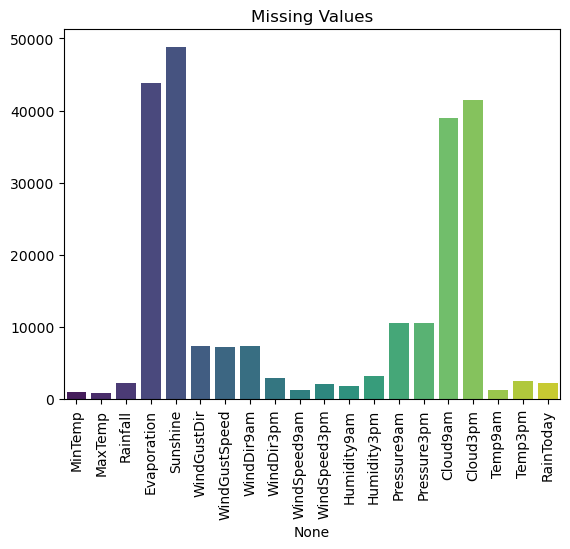

In [10]:
plt.Figure(figsize=(12,8))
missing = df.isnull().sum()
missing = missing[missing > 0]
sns.barplot(
    x = missing.index,
    y = missing.values,
    hue=missing.index,
        palette="viridis",
        legend=False
)
plt.xticks(rotation=90)
plt.title("Missing Values")
plt.show()

In [11]:
print("Duplicat Rows: ", df.duplicated().sum())

Duplicat Rows:  0


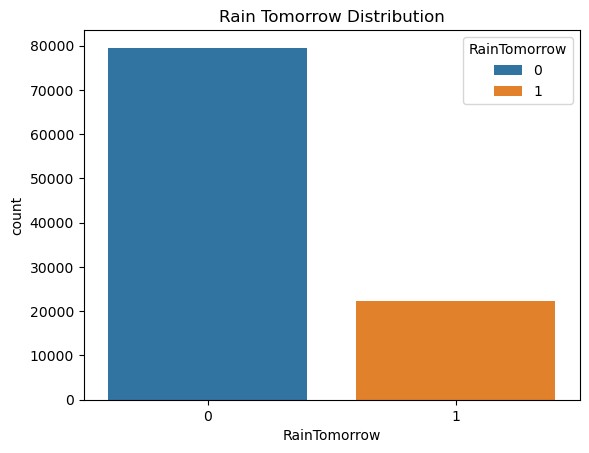

In [12]:
plt.Figure(figsize=(5,4))
sns.countplot(
    data = df,
    x = "RainTomorrow",
    hue="RainTomorrow",
)
plt.title("Rain Tomorrow Distribution")
plt.show()

In [13]:
df = df.drop("Date", axis=1)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [16]:
category_columns = df.select_dtypes(include="object").columns
for col in category_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
df.isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

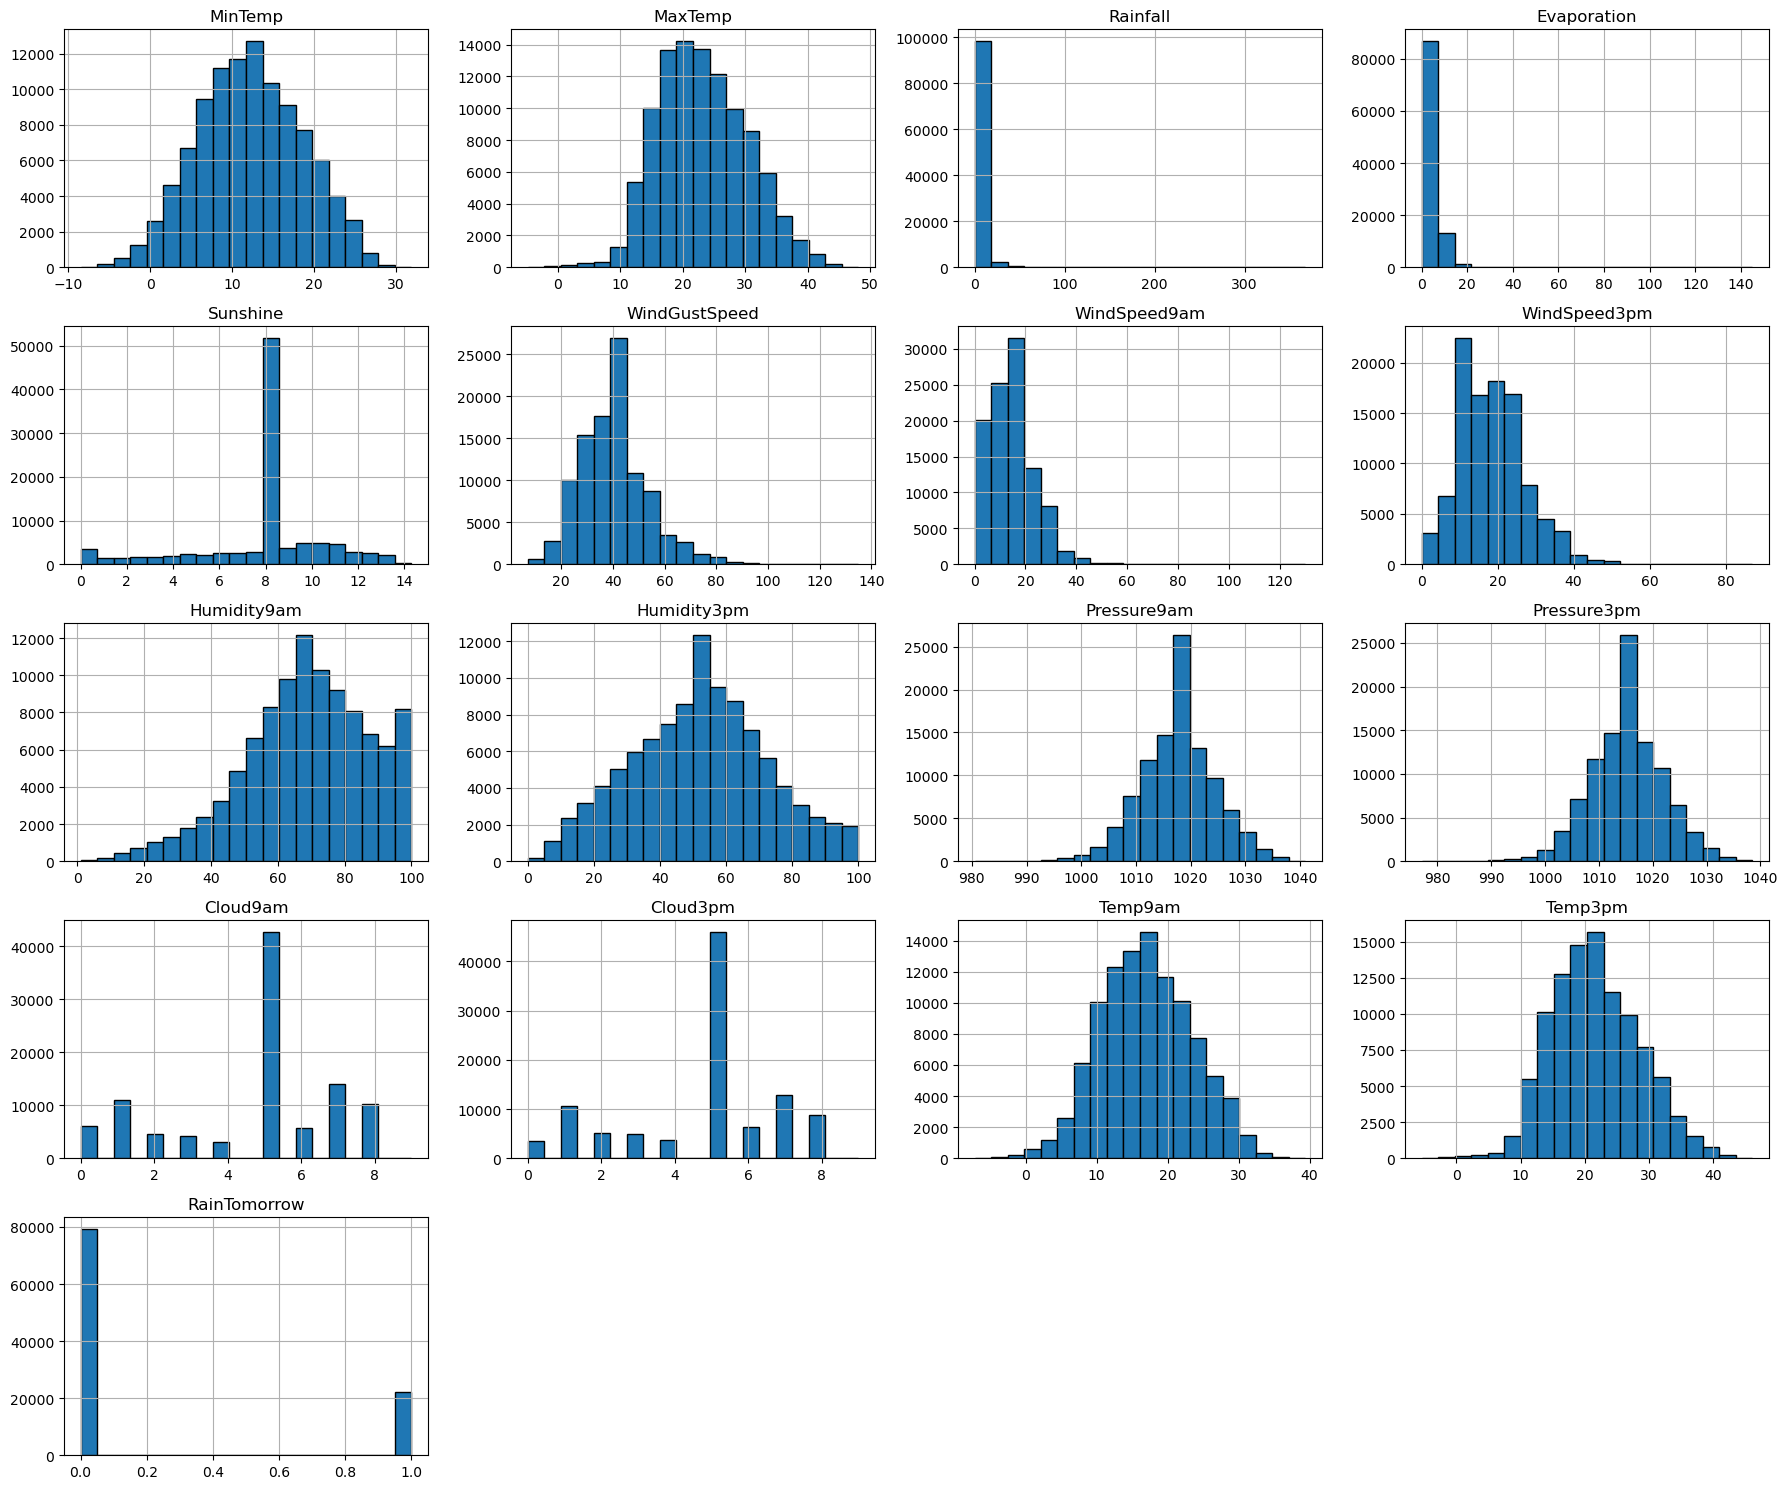

In [18]:
df.hist(
    figsize=(18,15),
    bins=20,
    edgecolor="black"
)
plt.tight_layout()
plt.show()

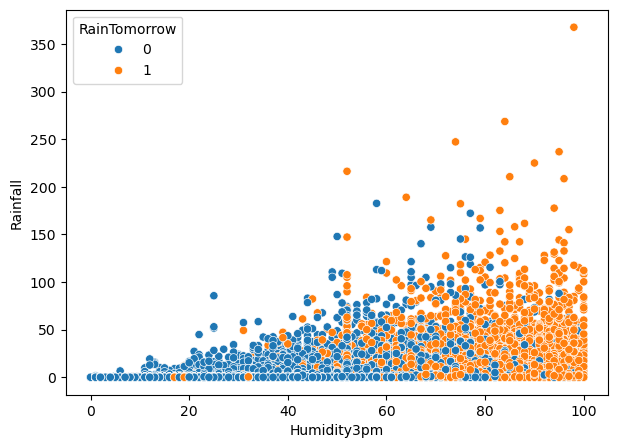

In [19]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Humidity3pm",
    y="Rainfall",
    hue="RainTomorrow"
)
plt.show()

In [20]:
#Part 2: Preprocessing

In [21]:
x = df.drop(columns="RainTomorrow")
y = df["RainTomorrow"]

numeric_feature = df.select_dtypes(include="number").columns
categorical_features = df.select_dtypes(include="object").columns
print("Numerical Features: \n", numeric_feature)
print("\n Categorical Features: \n", categorical_features)



Numerical Features: 
 Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainTomorrow'],
      dtype='object')

 Categorical Features: 
 Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')


In [22]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)
print(target_encoder.classes_)

[0 1]


In [23]:
#One Hot Encoder
X = pd.get_dummies(
    x,
    columns=categorical_features,
    drop_first=True)

print(X.shape)
X.head()

(101680, 110)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes
0,8.7,17.2,0.0,3.8,9.9,54.0,17.0,26.0,54.0,28.0,...,False,False,False,False,False,False,True,False,False,False
1,15.4,25.7,0.0,4.8,8.4,67.0,11.0,9.0,84.0,66.0,...,False,False,False,False,False,False,False,False,True,False
2,15.2,22.2,7.2,5.2,3.3,78.0,33.0,28.0,68.0,91.0,...,False,False,False,False,False,False,False,False,True,True
3,19.9,26.4,0.0,2.8,8.4,24.0,13.0,9.0,97.0,97.0,...,False,False,False,False,False,False,False,False,True,False
4,19.3,32.9,0.0,4.8,8.4,48.0,19.0,22.0,46.0,15.0,...,False,False,False,False,False,False,True,False,False,False


In [24]:
#Traininr
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)


(81344, 110)
(20336, 110)


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Data for tree-based models
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Data for distance/linear models
X_train_linear = X_train_scaled
X_test_linear = X_test_scaled

In [27]:
#Model 1: Logistic Regression

In [28]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
)
logistic_model.fit(X_train_scaled, y_train)
logistic_predi = logistic_model.predict(X_test_scaled)


In [29]:
print("Accuracy :", accuracy_score(y_test, logistic_predi))
print("Precision:", precision_score(y_test, logistic_predi))
print("Recall   :", recall_score(y_test, logistic_predi))
print("F1 Score :", f1_score(y_test, logistic_predi))

print("\nClassification Report\n")
print(classification_report(y_test, logistic_predi))

Accuracy : 0.8499704956726987
Precision: 0.732013201320132
Recall   : 0.49764415526138656
F1 Score : 0.5924936556698277

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     15879
           1       0.73      0.50      0.59      4457

    accuracy                           0.85     20336
   macro avg       0.80      0.72      0.75     20336
weighted avg       0.84      0.85      0.84     20336



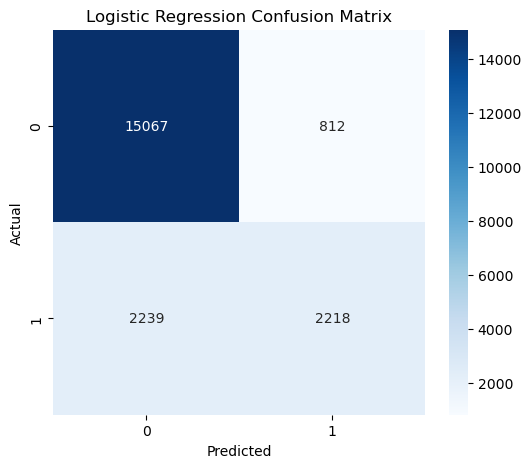

In [30]:
cm = confusion_matrix(y_test, logistic_predi)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
#Model 2: Decision Tree

In [32]:
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="entropy",
    random_state=42
)
decision_tree.fit(X_train, y_train)
decision_tree_predi = decision_tree.predict(X_test)

In [33]:
print("Accuracy :", accuracy_score(y_test, decision_tree_predi))
print("Precision:", precision_score(y_test, decision_tree_predi))
print("Recall   :", recall_score(y_test, decision_tree_predi))
print("F1 Score :", f1_score(y_test, decision_tree_predi))

print("\nClassification Report\n")
print(classification_report(y_test, decision_tree_predi))

Accuracy : 0.8413158929976396
Precision: 0.7147346368715084
Recall   : 0.4592775409468252
F1 Score : 0.5592132222373992

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.95      0.90     15879
           1       0.71      0.46      0.56      4457

    accuracy                           0.84     20336
   macro avg       0.79      0.70      0.73     20336
weighted avg       0.83      0.84      0.83     20336



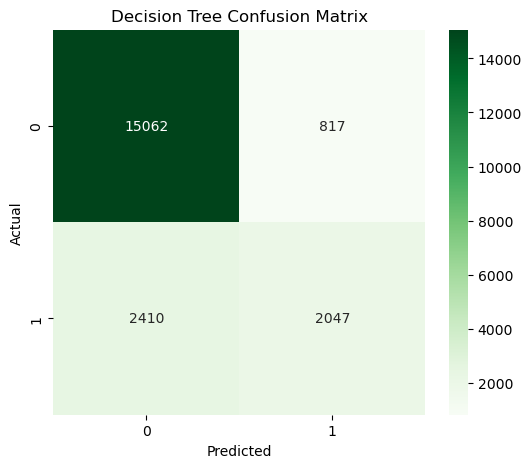

In [34]:
cm = confusion_matrix(y_test, decision_tree_predi)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
#Model 3: Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train_tree, y_train)

pred_rf = rf.predict(X_test_tree)

In [37]:
f1_train_test = f1_score(y_test, pred_rf)
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, pred_rf))

Accuracy : 0.8568548387096774
Precision: 0.7731448763250883
Recall   : 0.4909131702939197
F1 Score : 0.6005214766021683

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     15879
           1       0.77      0.49      0.60      4457

    accuracy                           0.86     20336
   macro avg       0.82      0.73      0.76     20336
weighted avg       0.85      0.86      0.84     20336



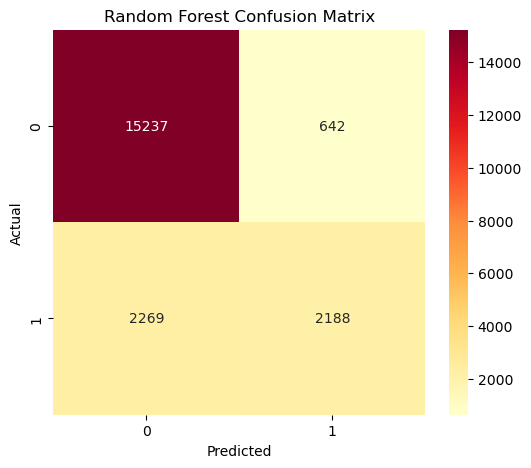

In [38]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
#Model 4: KNN

In [40]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_linear, y_train)

pred_knn = knn.predict(X_test_linear)

In [41]:
print("Accuracy :", accuracy_score(y_test, pred_knn))
print("Precision:", precision_score(y_test, pred_knn))
print("Recall   :", recall_score(y_test, pred_knn))
print("F1 Score :", f1_score(y_test, pred_knn))

print("\nClassification Report\n")
print(classification_report(y_test, pred_knn))

Accuracy : 0.8055664830841857
Precision: 0.6074327210593763
Recall   : 0.31904868745793136
F1 Score : 0.4183583406884378

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.94      0.88     15879
           1       0.61      0.32      0.42      4457

    accuracy                           0.81     20336
   macro avg       0.72      0.63      0.65     20336
weighted avg       0.78      0.81      0.78     20336



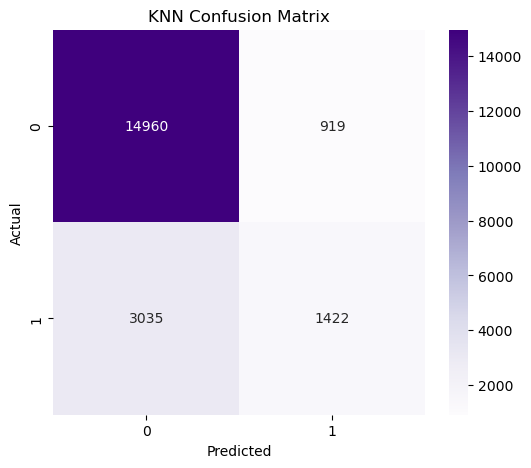

In [42]:
cm = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
#Model 5: SVC

In [44]:
svm = SVC(
    kernel="linear",
    random_state=42
)

svm.fit(X_train_linear, y_train)

pred_svm = svm.predict(X_test_linear)

In [45]:
print("Accuracy :", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall   :", recall_score(y_test, pred_svm))
print("F1 Score :", f1_score(y_test, pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, pred_svm))

Accuracy : 0.8504130605822188
Precision: 0.7564334903950707
Recall   : 0.46825218757011444
F1 Score : 0.5784368070953437

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     15879
           1       0.76      0.47      0.58      4457

    accuracy                           0.85     20336
   macro avg       0.81      0.71      0.74     20336
weighted avg       0.84      0.85      0.84     20336



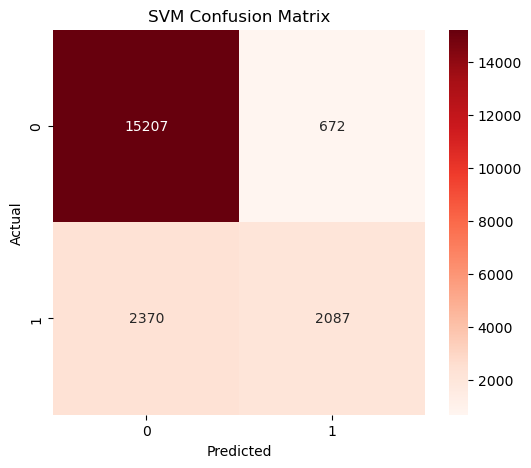

In [46]:
cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_linear, y_train)

pred_nb = nb.predict(X_test_linear)

In [48]:
print("Accuracy :", accuracy_score(y_test, pred_nb))
print("Precision:", precision_score(y_test, pred_nb))
print("Recall   :", recall_score(y_test, pred_nb))
print("F1 Score :", f1_score(y_test, pred_nb))

print("\nClassification Report\n")
print(classification_report(y_test, pred_nb))

Accuracy : 0.641079858379229
Precision: 0.3445975503062117
Recall   : 0.7069777877496074
F1 Score : 0.4633482832144695

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.62      0.73     15879
           1       0.34      0.71      0.46      4457

    accuracy                           0.64     20336
   macro avg       0.61      0.66      0.60     20336
weighted avg       0.77      0.64      0.67     20336



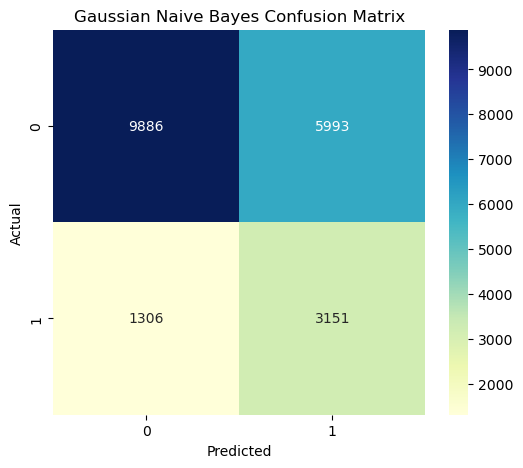

In [49]:
cm = confusion_matrix(y_test, pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        # "SVM",
        "KNN",
        "Naive Bayes",

    ],

    "Accuracy": [
        accuracy_score(y_test,logistic_predi),
        accuracy_score(y_test,decision_tree_predi),
        accuracy_score(y_test,pred_rf),
        # accuracy_score(y_test,pred_svm),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_nb),

    ],

    "Precision":[
        precision_score(y_test,logistic_predi),
        precision_score(y_test,decision_tree_predi),
        precision_score(y_test,pred_rf),
        # precision_score(y_test,pred_svm),
        precision_score(y_test,pred_knn),
        precision_score(y_test,pred_nb),

    ],

    "Recall":[
        recall_score(y_test,logistic_predi),
        recall_score(y_test,decision_tree_predi),
        recall_score(y_test,pred_rf),
        # recall_score(y_test,pred_svm),
        recall_score(y_test,pred_knn),
        recall_score(y_test,pred_nb),

    ],

    "F1 Score":[
        f1_score(y_test,logistic_predi),
        f1_score(y_test,decision_tree_predi),
        f1_score(y_test,pred_rf),
        # f1_score(y_test,pred_svm),
        f1_score(y_test,pred_knn),
        f1_score(y_test,pred_nb),

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.849970,0.732013,0.497644,0.592494
1,Decision Tree,0.841316,0.714735,0.459278,0.559213
2,Random Forest,0.856855,0.773145,0.490913,0.600521
3,KNN,0.805566,0.607433,0.319049,0.418358
4,Naive Bayes,0.641080,0.344598,0.706978,0.463348


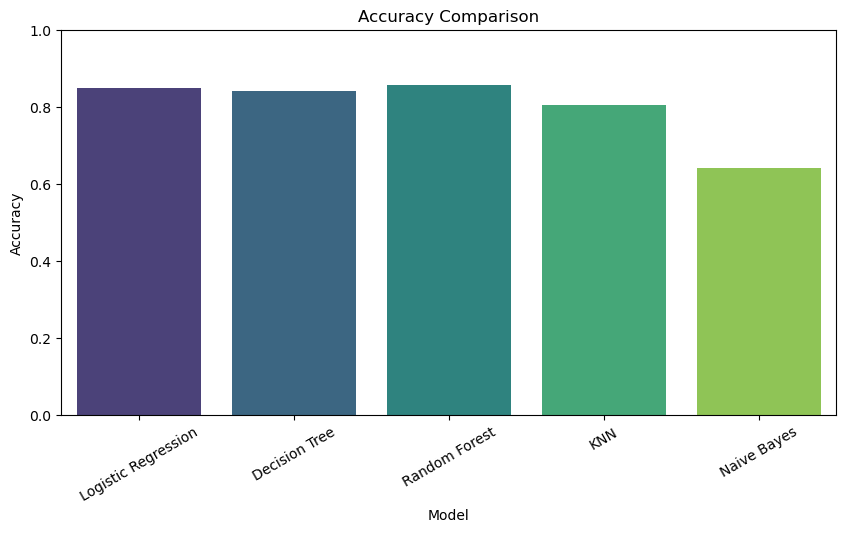

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=30)

plt.title("Accuracy Comparison")

plt.ylim(0,1)

plt.show()

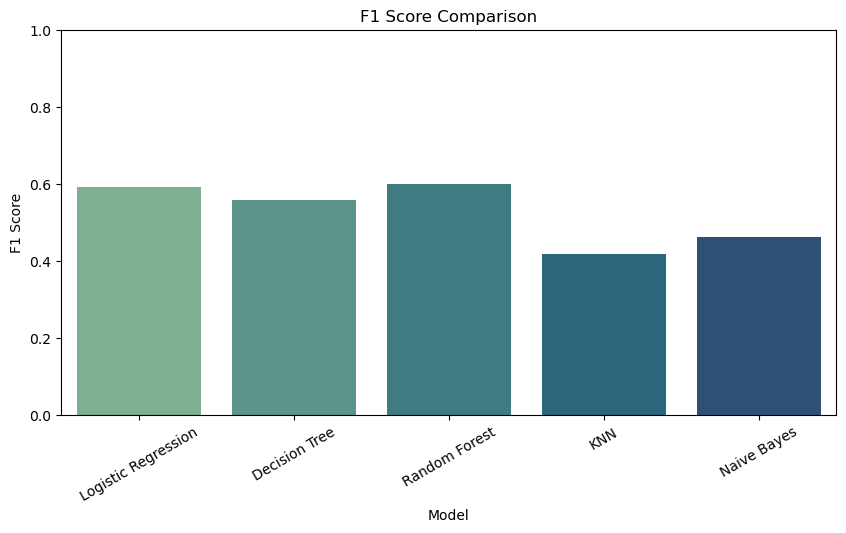

In [52]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score",
    hue="Model",
    palette="crest",
    legend=False
)

plt.xticks(rotation=30)

plt.title("F1 Score Comparison")

plt.ylim(0,1)

plt.show()

In [ ]:
#cross validation
scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

In [ ]:

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.4f}")

f1_cross_val = scores.mean()
print("Mean F1 Score : ", f1_cross_val)

In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Train/Test Split",
        "5-Fold Cross Validation"
    ],
    "F1 Score": [
        f1_train_test,
        f1_cross_val
    ]
})

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=comparison,
    x="Method",
    y="F1 Score",
    hue="Method",
    palette="crest",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.title("Random Forest F1 Score Comparison")
plt.ylim(0,1)

plt.show()

In [ ]:
import joblib

joblib.dump(rf, "weather_model.pkl")
joblib.dump(scaler, "weather_scaler.pkl")
joblib.dump(target_encoder, "weather_encoder.pkl")
joblib.dump(X.columns.tolist(), "weather_columns.pkl")